In [1]:
import pandas as pd
import numpy as np
import toolkit
import pickle as pkl

In [2]:
with open("data/train.pkl", "rb") as file:
    train = pkl.load(file)

In [3]:
with open("data/test.pkl", "rb") as file:
    test = pkl.load(file)

In [4]:
train.shape, test.shape

((10628, 2), (1181, 2))

In [5]:
train.head()

,Status,Message
2870,0,From ilug-admin@linux.ie Thu Aug 29 16:42:34 ...
13153,0,From rssfeeds@jmason.org Thu Sep 26 16:43:26 ...
4278,0,From spamassassin-talk-admin@lists.sourceforge...
4038,2,From jm@netnoteinc.com Mon Jul 29 11:22:06 20...
774,0,From fork-admin@xent.com Mon Sep 23 15:00:49 ...


In [6]:
test.head()

,Status,Message
3151,0,From fork-admin@xent.com Mon Aug 26 15:31:43 ...
14125,0,From ilug-admin@linux.ie Tue Aug 20 12:43:52 ...
2364,2,From rory007460171i01@edtnmail.com Tue Jul 23...
3905,2,From densua@Flashmail.com Wed Jul 24 15:16:32...
7474,0,From fork-admin@xent.com Sat Sep 7 21:52:12 ...


In [7]:
train = toolkit.introductory_pipeline(train)
test = toolkit.introductory_pipeline(test)

In [8]:
train.head()

,.,.>,2002,the,from,with,.Received:,+0100,a,for,...,.Reply-To:,our,<a,.<table,We,/>,.<td,Helvetica,Status,domain
0,20,14,9,9,7,7,7,5,5,4,...,0,0,0,0,0,0,0,0,0,linux.ie
1,6,0,5,0,3,3,3,3,0,1,...,0,0,0,0,0,0,0,0,0,jmason.org
2,21,9,11,2,8,8,8,4,2,3,...,0,0,0,0,0,0,0,0,0,lists.sourceforge.net
3,35,0,6,12,5,6,4,2,5,4,...,1,3,1,0,0,0,12,10,2,unimportant
4,16,0,8,1,6,5,6,3,1,4,...,0,0,0,0,0,0,0,0,0,xent.com


In [9]:
test.head()

,.,.>,2002,the,from,with,.Received:,+0100,a,for,...,.Reply-To:,our,<a,.<table,We,/>,.<td,Helvetica,Status,domain
0,17,0,10,3,7,6,7,2,1,2,...,0,0,0,0,0,0,0,0,0,xent.com
1,14,0,8,1,5,6,6,6,1,3,...,0,0,0,0,0,0,0,0,0,linux.ie
2,9,0,5,0,4,4,4,3,0,2,...,1,0,0,0,0,0,0,0,2,unimportant
3,9,0,7,3,6,5,5,3,1,2,...,0,0,1,0,0,0,0,2,2,Flashmail.com
4,14,0,10,1,7,6,7,3,4,2,...,0,0,0,0,0,0,0,0,0,xent.com


In [10]:
with open("data/preprocessed_trainig.pkl", "wb") as file:
    pkl.dump(train, file)
with open("data/preprocessed_test.pkl", "wb") as file:
    pkl.dump(test, file)

In [11]:
len(train["domain"].unique())

34

In [12]:
train["domain"].isna().mean()

np.float64(0.0)

In [13]:
test["domain"].value_counts()

domain
xent.com                    310
jmason.org                  177
unimportant                 152
lists.sourceforge.net        98
freshrpms.net                87
linux.ie                     75
unknown                      71
redhat.com                   62
hotmail.com                  25
perl.org                     20
returns.groups.yahoo.com     16
yahoo.com                    15
msn.com                       8
SMTP1.ADMANMAIL.COM           6
petting-zoo.net               6
pathname.com                  6
eudoramail.com                6
insurancemail.net             6
securityfocus.com             5
insiq.us                      5
aol.com                       4
btamail.net.cn                4
python.org                    3
spamassassin.taint.org        2
taint.org                     2
example.com                   2
excite.com                    2
Flashmail.com                 1
caramail.com                  1
srv0.ems.ed.ac.uk             1
2ubh.com                      1
m

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
counted = train.groupby(["domain", "Status"]).size().reset_index(name="count")

In [16]:
counted = counted.merge(train.groupby(["domain"]).size().reset_index(name="sum"), how="left", on="domain")

In [17]:
counted["count"] = counted["count"] / counted["sum"]

In [18]:
counted

,domain,Status,count,sum
0,2ubh.com,0,1.000000,19
1,Flashmail.com,2,1.000000,24
2,SMTP1.ADMANMAIL.COM,2,1.000000,27
3,aol.com,2,1.000000,67
4,btamail.net.cn,2,1.000000,29
5,caramail.com,2,1.000000,21
6,comcast.net,0,1.000000,16
7,dogma.slashnull.org,0,0.777778,18
8,dogma.slashnull.org,1,0.111111,18
9,dogma.slashnull.org,2,0.111111,18


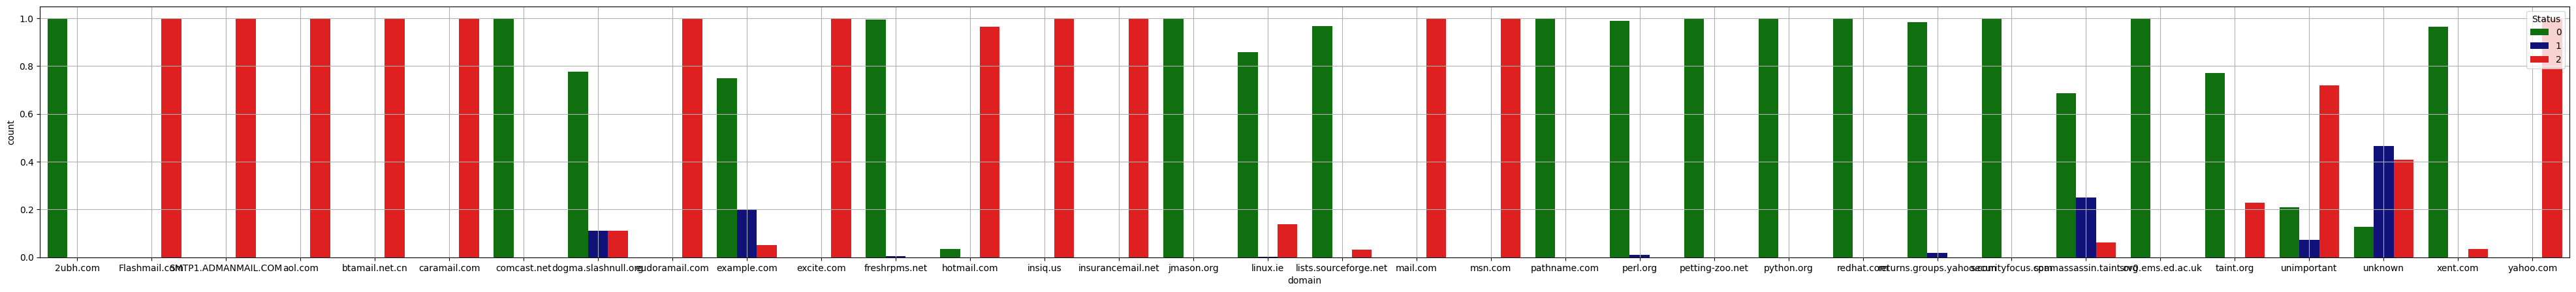

In [19]:
plt.figure(figsize=(50, 5))
sns.barplot(data=counted, x="domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()